In [2]:
from google.colab import files
uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset (1).csv


In [3]:
import pandas as pd
import sqlite3

df = pd.read_csv("retail_sales_dataset.csv")

conn = sqlite3.connect("retail_sales.db")
df.to_sql("retail_sales", conn, if_exists="replace", index=False)

print("Loaded into SQLite:", conn.execute("SELECT COUNT(*) FROM retail_sales").fetchone())

Loaded into SQLite: (1000,)


In [4]:
q1 = """
SELECT "Product Category", SUM("Total Amount") AS total_revenue
FROM retail_sales
GROUP BY "Product Category"
ORDER BY total_revenue DESC;
"""
category_revenue = pd.read_sql_query(q1, conn)
category_revenue

,Product Category,total_revenue
0,Electronics,156905
1,Clothing,155580
2,Beauty,143515


In [5]:
q2 = """
SELECT "Customer ID", SUM("Total Amount") AS total_spent
FROM retail_sales
GROUP BY "Customer ID"
ORDER BY total_spent DESC
LIMIT 10;
"""
top_customers = pd.read_sql_query(q2, conn)
top_customers

,Customer ID,total_spent
0,CUST970,2000
1,CUST946,2000
2,CUST927,2000
3,CUST875,2000
4,CUST832,2000
5,CUST808,2000
6,CUST789,2000
7,CUST773,2000
8,CUST743,2000
9,CUST742,2000


In [6]:
q3 = """
SELECT strftime('%m', Date) AS month, SUM("Total Amount") AS revenue
FROM retail_sales
GROUP BY month
ORDER BY month;
"""
monthly_trend = pd.read_sql_query(q3, conn)
monthly_trend

,month,revenue
0,01,36980
1,02,44060
2,03,28990
3,04,33870
4,05,53150
5,06,36715
6,07,35465
7,08,36960
8,09,23620
9,10,46580


In [7]:
q4 = """
SELECT Gender, SUM("Total Amount") AS total_revenue, COUNT(*) AS transactions
FROM retail_sales
GROUP BY Gender;
"""
gender_revenue = pd.read_sql_query(q4, conn)
gender_revenue

,Gender,total_revenue,transactions
0,Female,232840,510
1,Male,223160,490


In [8]:
queries = {"category_revenue": q1, "top_customers": q2, "monthly_trend": q3, "gender_revenue": q4}
with open("queries.sql", "w") as f:
    for name, q in queries.items():
        f.write(f"-- {name}\n{q.strip()}\n\n")

files.download("queries.sql")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_1420/1486741271.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_revenue, x="total_revenue", y="Product Category", palette="viridis")


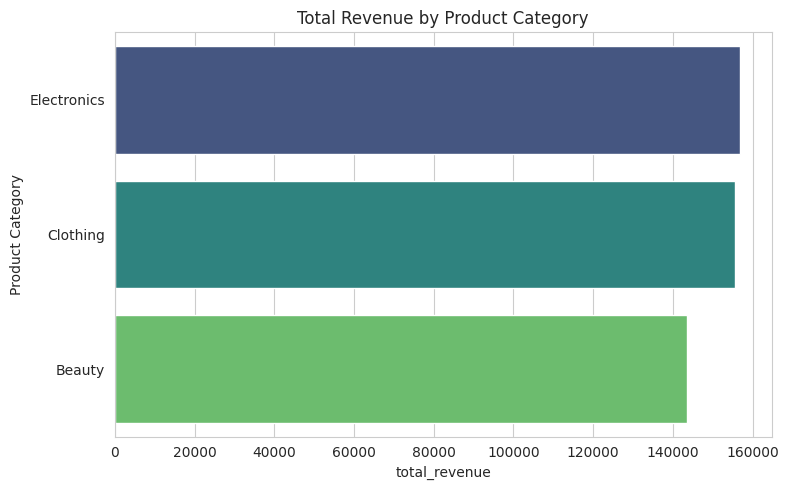

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(data=category_revenue, x="total_revenue", y="Product Category", palette="viridis")
plt.title("Total Revenue by Product Category")
plt.tight_layout()
plt.savefig("category_revenue.png")
plt.show()
files.download("category_revenue.png")